# Triple Extraction Pipeline Analysis

This notebook loads, assembles, and compares results from all triple extraction pipeline stages:
- Semantic Chunking
- Extraction
- Triple Repair
- Canonicalization

In [1]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict, Counter
from typing import Dict, List, Any, Optional, Set, Tuple
from dataclasses import dataclass, asdict
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Configuration

In [2]:
# Path to results directory
RESULTS_DIR = Path("../results/triple_extraction")

# Stages to analyze
STAGES = ["semantic_chunking", "extraction", "triple_repair", "canonicalization"]

# Run ID to analyze (None = use most recent)
RUN_ID = "20260313-123818"  # 707-doc gemma3-cti-4b run

## Helper Functions

In [3]:
def load_jsonl(file_path: Path) -> List[Dict[str, Any]]:
    """Load JSONL file and return list of dicts."""
    data = []
    if file_path.exists():
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line:
                    try:
                        data.append(json.loads(line))
                    except json.JSONDecodeError as e:
                        print(f"Warning: Failed to parse line in {file_path.name}: {e}")
    return data


def load_json(file_path: Path) -> List[Dict[str, Any]]:
    """Load JSON file and return list of dicts."""
    if file_path.exists():
        with open(file_path, 'r', encoding='utf-8') as f:
            return json.load(f)
    return []


def get_triple_key(triple: Dict[str, Any]) -> Tuple[str, str, str]:
    """Generate a unique key for a triple (subject, predicate, object)."""
    def get_name(entity):
        if isinstance(entity, dict):
            return entity.get("name", "").lower().strip()
        return str(entity).lower().strip()
    
    subj = triple.get("subject", {})
    obj = triple.get("object", {})
    pred = triple.get("predicate", "").lower().strip()
    
    return (get_name(subj), pred, get_name(obj))


def extract_entities_from_triples(triples: List[Dict[str, Any]]) -> Set[str]:
    """Extract unique entity names from triples."""
    entities = set()
    for t in triples:
        subj = t.get("subject", {})
        obj = t.get("object", {})
        
        if isinstance(subj, dict):
            entities.add(subj.get("name", "").lower().strip())
        else:
            entities.add(str(subj).lower().strip())
            
        if isinstance(obj, dict):
            entities.add(obj.get("name", "").lower().strip())
        else:
            entities.add(str(obj).lower().strip())
    
    return entities - {""}  # Remove empty strings

## Find Available Run IDs

In [4]:
def find_available_runs() -> List[str]:
    """Find all available run_ids across all stages."""
    run_ids = set()
    
    for stage in STAGES:
        stage_dir = RESULTS_DIR / stage
        if stage_dir.exists():
            for file_path in stage_dir.glob("*.json*"):
                # Extract run_id from filename (format: {run_id}.json or {run_id}.jsonl)
                run_id = file_path.stem
                run_ids.add(run_id)
    
    return sorted(run_ids, reverse=True)  # Most recent first


available_runs = find_available_runs()
print(f"Found {len(available_runs)} run(s):")
for run_id in available_runs[:10]:  # Show first 10
    print(f"  - {run_id}")

if RUN_ID is None and available_runs:
    RUN_ID = available_runs[0]
    print(f"\nUsing most recent run: {RUN_ID}")
elif RUN_ID and RUN_ID not in available_runs:
    print(f"\nWarning: Run ID {RUN_ID} not found. Available runs: {available_runs[:5]}")
    RUN_ID = available_runs[0] if available_runs else None

Found 26 run(s):
  - 20260313-123818
  - 20260313-123337
  - 20260313-123328
  - 20260313-123315
  - 20260311-171204
  - 20260310-143757
  - 20260310-132346
  - 20260310-120451
  - 20260304-180445
  - 20260304-141028


## Load Results from All Stages

In [5]:
def load_stage_results(run_id: str, stage: str) -> List[Dict[str, Any]]:
    """Load results for a specific stage and run_id."""
    stage_dir = RESULTS_DIR / stage
    
    # Try JSONL first (for large files)
    jsonl_path = stage_dir / f"{run_id}.jsonl"
    if jsonl_path.exists():
        return load_jsonl(jsonl_path)
    
    # Try JSON
    json_path = stage_dir / f"{run_id}.json"
    if json_path.exists():
        return load_json(json_path)
    
    return []


if RUN_ID:
    print(f"Loading results for run_id: {RUN_ID}\n")
    
    stage_results = {}
    for stage in STAGES:
        results = load_stage_results(RUN_ID, stage)
        stage_results[stage] = results
        print(f"{stage:20s}: {len(results):5d} batches")
    
    print(f"\nÃ¢Å“â€œ Loaded results from {len([s for s in STAGES if stage_results[s]])} stage(s)")
else:
    print("No run_id available. Please check available runs above.")
    stage_results = {}

Loading results for run_id: 20260313-123818

semantic_chunking   :   707 batches
extraction          :   707 batches
triple_repair       :     0 batches
canonicalization    :     0 batches

Ã¢Å“â€œ Loaded results from 2 stage(s)


## Compute Statistics for Each Stage

In [6]:
def compute_stage_stats(stage_name: str, batches: List[Dict[str, Any]]) -> Dict[str, Any]:
    """Compute statistics for a stage."""
    total_batches = len(batches)
    total_triples = 0
    total_entities = set()
    predicates = Counter()
    entity_types = Counter()
    doc_ids = set()
    
    for batch in batches:
        doc_id = batch.get("doc_id", "")
        if doc_id:
            doc_ids.add(doc_id)
        
        triples = batch.get("triples", [])
        total_triples += len(triples)
        
        # Extract entities and predicates
        batch_entities = extract_entities_from_triples(triples)
        total_entities.update(batch_entities)
        
        for t in triples:
            pred = t.get("predicate", "").lower().strip()
            if pred:
                predicates[pred] += 1
            
            # Extract entity types
            subj = t.get("subject", {})
            obj = t.get("object", {})
            
            if isinstance(subj, dict):
                subj_type = subj.get("type")
                if subj_type:
                    entity_types[subj_type] += 1
            
            if isinstance(obj, dict):
                obj_type = obj.get("type")
                if obj_type:
                    entity_types[obj_type] += 1
    
    return {
        "stage": stage_name,
        "total_batches": total_batches,
        "total_documents": len(doc_ids),
        "total_triples": total_triples,
        "total_unique_entities": len(total_entities),
        "avg_triples_per_batch": total_triples / total_batches if total_batches > 0 else 0,
        "top_predicates": dict(predicates.most_common(10)),
        "top_entity_types": dict(entity_types.most_common(10)),
        "all_entities": total_entities,
        "all_triples": batches,
    }


if RUN_ID and stage_results:
    stage_stats = {}
    for stage in STAGES:
        if stage in stage_results and stage_results[stage]:
            stats = compute_stage_stats(stage, stage_results[stage])
            stage_stats[stage] = stats
    
    # Display summary table
    summary_data = []
    for stage, stats in stage_stats.items():
        summary_data.append({
            "Stage": stage.replace("_", " ").title(),
            "Batches": stats["total_batches"],
            "Documents": stats["total_documents"],
            "Triples": stats["total_triples"],
            "Unique Entities": stats["total_unique_entities"],
            "Avg Triples/Batch": f"{stats['avg_triples_per_batch']:.2f}",
        })
    
    df_summary = pd.DataFrame(summary_data)
    print("\n" + "="*80)
    print("STAGE SUMMARY STATISTICS")
    print("="*80)
    print(df_summary.to_string(index=False))
else:
    stage_stats = {}


STAGE SUMMARY STATISTICS
            Stage  Batches  Documents  Triples  Unique Entities Avg Triples/Batch
Semantic Chunking      707        707        0                0              0.00
       Extraction      707        707     3189             1585              4.51


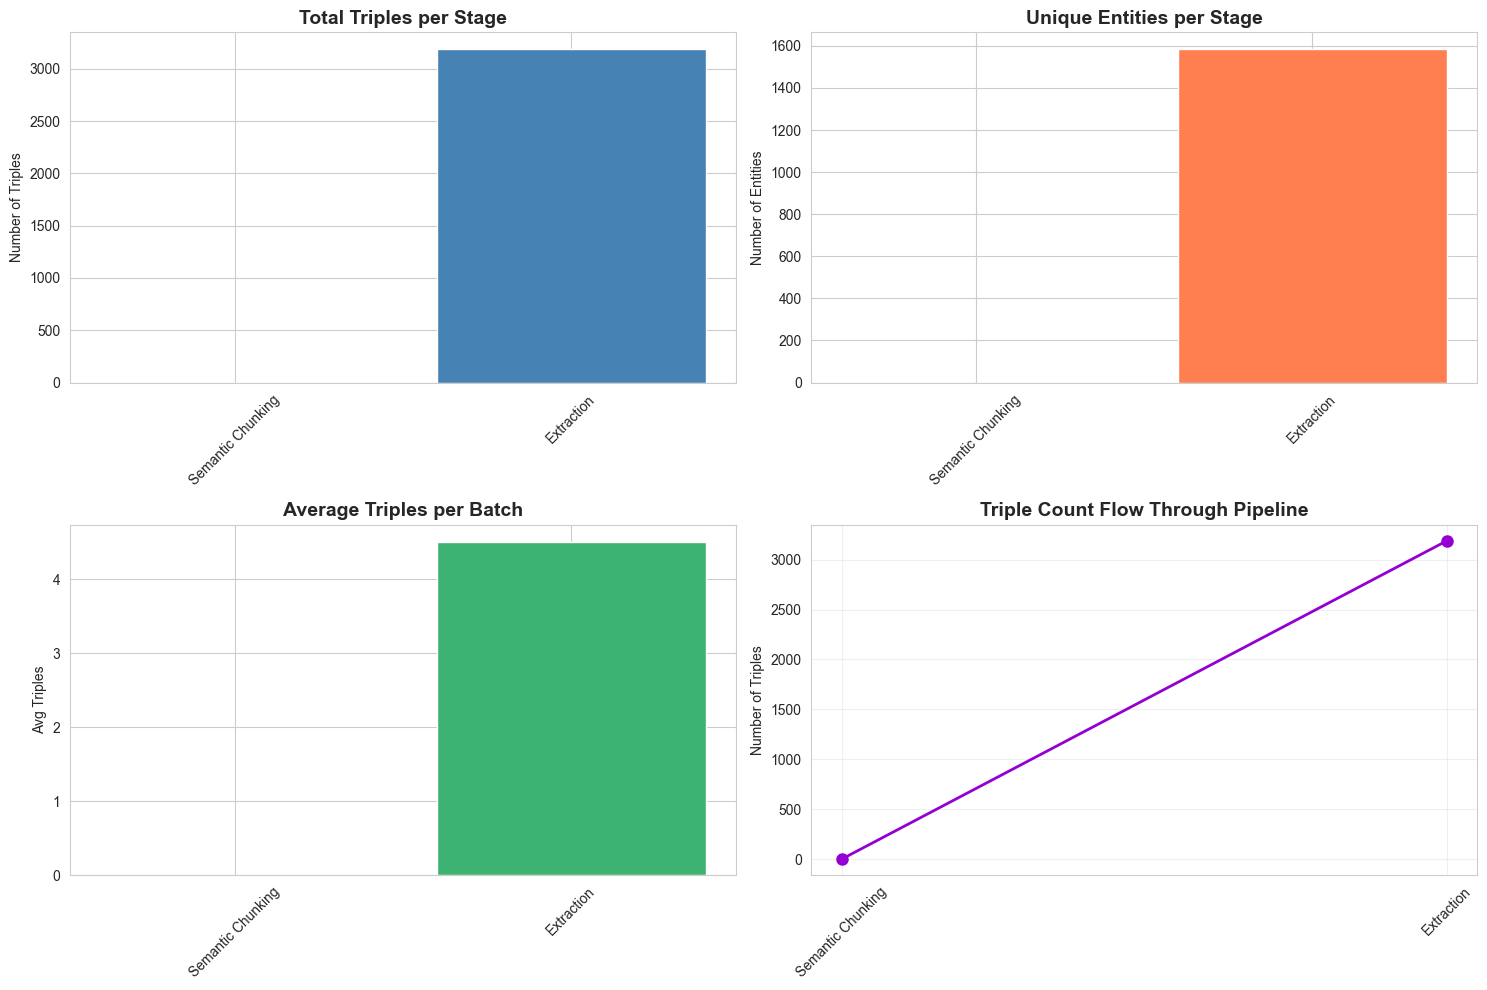


Run ID: 20260313-123818


In [7]:
if stage_stats:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    stages = list(stage_stats.keys())
    stage_labels = [s.replace("_", " ").title() for s in stages]
    
    # 1. Total Triples
    axes[0, 0].bar(stage_labels, [stage_stats[s]["total_triples"] for s in stages], color='steelblue')
    axes[0, 0].set_title("Total Triples per Stage", fontsize=14, fontweight='bold')
    axes[0, 0].set_ylabel("Number of Triples")
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # 2. Unique Entities
    axes[0, 1].bar(stage_labels, [stage_stats[s]["total_unique_entities"] for s in stages], color='coral')
    axes[0, 1].set_title("Unique Entities per Stage", fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel("Number of Entities")
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # 3. Average Triples per Batch
    axes[1, 0].bar(stage_labels, [stage_stats[s]["avg_triples_per_batch"] for s in stages], color='mediumseagreen')
    axes[1, 0].set_title("Average Triples per Batch", fontsize=14, fontweight='bold')
    axes[1, 0].set_ylabel("Avg Triples")
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # 4. Triples Flow (line chart showing changes)
    triple_counts = [stage_stats[s]["total_triples"] for s in stages]
    axes[1, 1].plot(stage_labels, triple_counts, marker='o', linewidth=2, markersize=8, color='darkviolet')
    axes[1, 1].set_title("Triple Count Flow Through Pipeline", fontsize=14, fontweight='bold')
    axes[1, 1].set_ylabel("Number of Triples")
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nRun ID: {RUN_ID}")

## Compare Triples Between Stages

In [8]:
def get_triples_from_batches(batches: List[Dict[str, Any]]) -> Dict[Tuple[str, str, str], Dict[str, Any]]:
    """Extract all triples from batches, keyed by (subject, predicate, object)."""
    triples_dict = {}
    for batch in batches:
        for triple in batch.get("triples", []):
            key = get_triple_key(triple)
            triples_dict[key] = triple
    return triples_dict


if len(stage_stats) >= 2:
    print("\n" + "="*80)
    print("TRIPLE COMPARISON BETWEEN STAGES")
    print("="*80)
    
    # Get triples from each stage
    stage_triples = {}
    for stage in STAGES:
        if stage in stage_stats:
            stage_triples[stage] = get_triples_from_batches(stage_stats[stage]["all_triples"])
    
    # Compare consecutive stages
    comparison_data = []
    
    for i in range(len(STAGES) - 1):
        stage1 = STAGES[i]
        stage2 = STAGES[i + 1]
        
        if stage1 in stage_triples and stage2 in stage_triples:
            triples1 = stage_triples[stage1]
            triples2 = stage_triples[stage2]
            
            keys1 = set(triples1.keys())
            keys2 = set(triples2.keys())
            
            added = keys2 - keys1
            removed = keys1 - keys2
            common = keys1 & keys2
            
            comparison_data.append({
                "From Stage": stage1.replace("_", " ").title(),
                "To Stage": stage2.replace("_", " ").title(),
                "Common": len(common),
                "Added": len(added),
                "Removed": len(removed),
                "Net Change": len(added) - len(removed),
            })
            
            print(f"\n{stage1} Ã¢â€ â€™ {stage2}:")
            print(f"  Common triples:  {len(common):5d}")
            print(f"  Added triples:   {len(added):5d}")
            print(f"  Removed triples: {len(removed):5d}")
            print(f"  Net change:      {len(added) - len(removed):+5d}")
    
    if comparison_data:
        df_comparison = pd.DataFrame(comparison_data)
        print("\n" + "="*80)
        print("COMPARISON TABLE")
        print("="*80)
        print(df_comparison.to_string(index=False))
else:
    print("Need at least 2 stages with results to compare.")


TRIPLE COMPARISON BETWEEN STAGES

semantic_chunking Ã¢â€ â€™ extraction:
  Common triples:      0
  Added triples:    2872
  Removed triples:     0
  Net change:      +2872

COMPARISON TABLE
       From Stage   To Stage  Common  Added  Removed  Net Change
Semantic Chunking Extraction       0   2872        0        2872


## Top Predicates and Entity Types

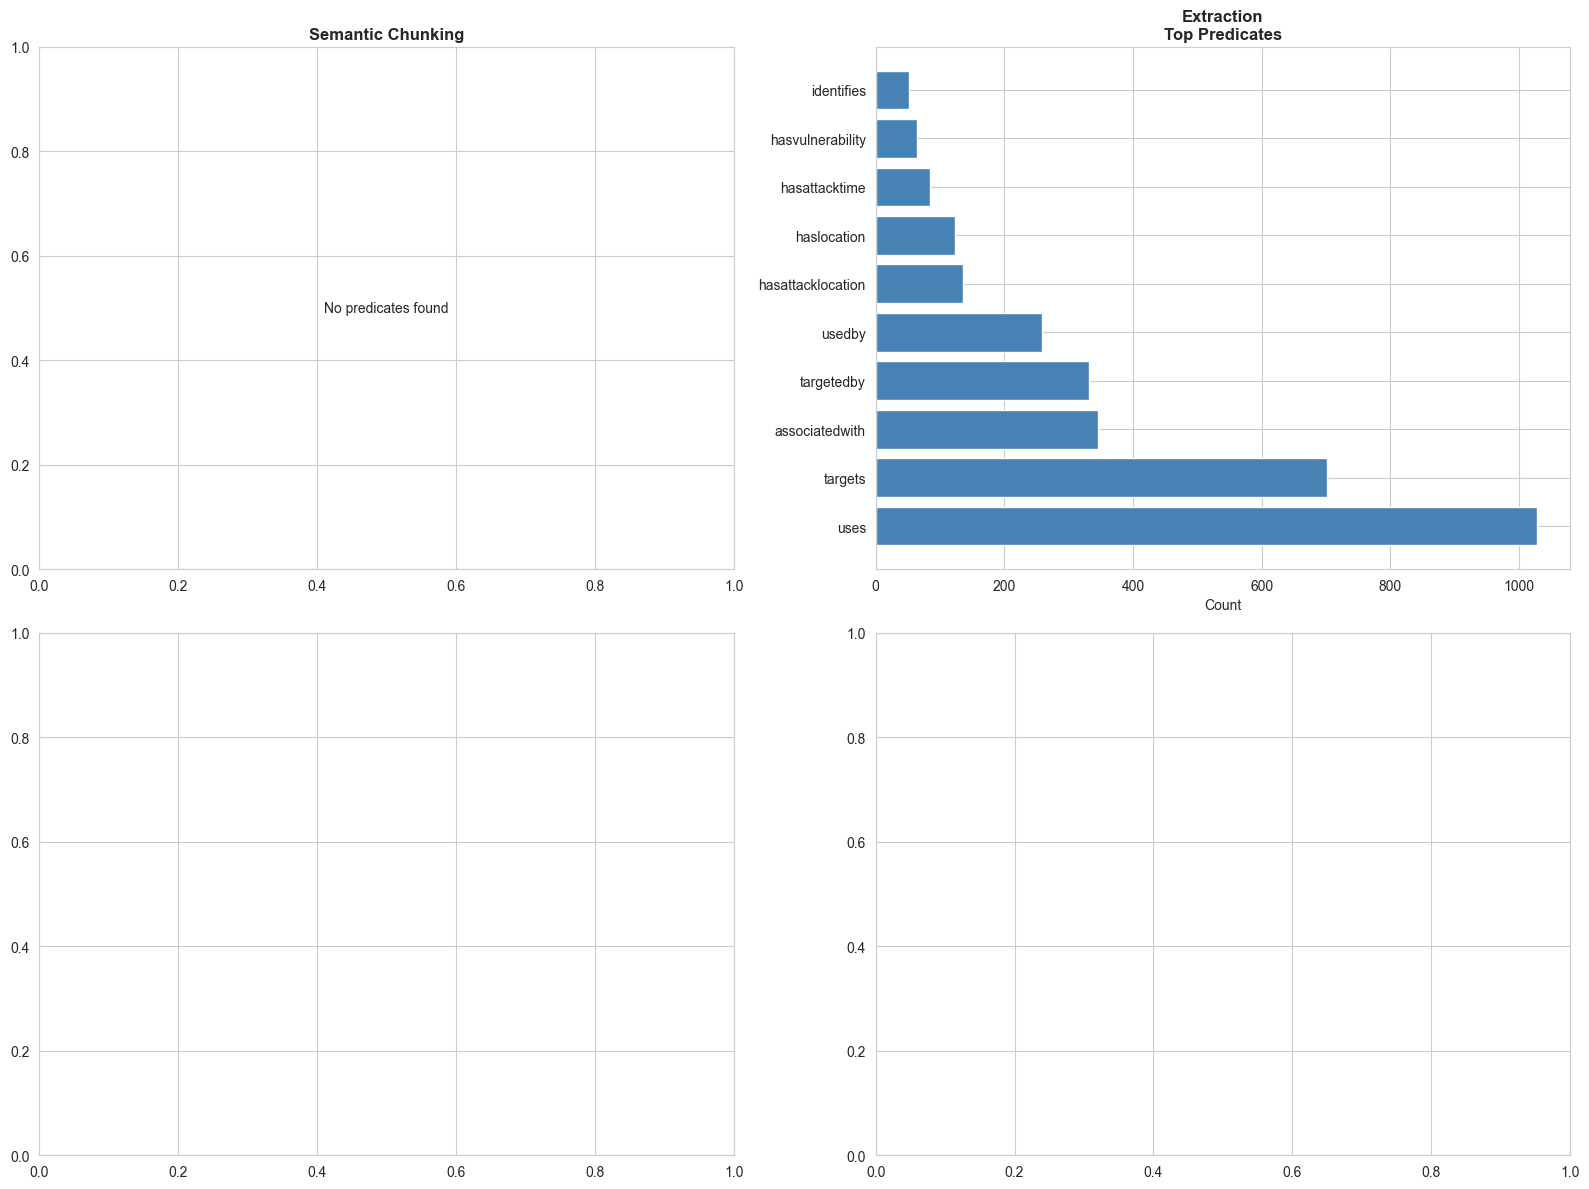

In [9]:
if stage_stats:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Show top predicates and entity types for each stage
    for idx, (stage, stats) in enumerate(list(stage_stats.items())[:4]):
        row = idx // 2
        col = idx % 2
        ax = axes[row, col]
        
        # Combine predicates and entity types
        predicates = stats["top_predicates"]
        entity_types = stats["top_entity_types"]
        
        if predicates:
            pred_items = list(predicates.items())[:10]
            pred_names = [p[0] for p in pred_items]
            pred_counts = [p[1] for p in pred_items]
            
            ax.barh(pred_names, pred_counts, color='steelblue')
            ax.set_title(f"{stage.replace('_', ' ').title()}\nTop Predicates", fontsize=12, fontweight='bold')
            ax.set_xlabel("Count")
        else:
            ax.text(0.5, 0.5, "No predicates found", ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{stage.replace('_', ' ').title()}", fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

## Sample Triples from Each Stage

In [10]:
def format_triple(triple: Dict[str, Any]) -> str:
    """Format a triple for display."""
    def get_name(entity):
        if isinstance(entity, dict):
            name = entity.get("name", "")
            etype = entity.get("type")
            if etype:
                return f"{name} ({etype})"
            return name
        return str(entity)
    
    subj = get_name(triple.get("subject", {}))
    pred = triple.get("predicate", "")
    obj = get_name(triple.get("object", {}))
    
    return f"({subj}, {pred}, {obj})"


if stage_stats:
    print("\n" + "="*80)
    print("SAMPLE TRIPLES FROM EACH STAGE")
    print("="*80)
    
    for stage, stats in stage_stats.items():
        print(f"\n{stage.replace('_', ' ').title()}:")
        print("-" * 80)
        
        # Get first batch with triples
        batches = stats["all_triples"]
        sample_triples = []
        
        for batch in batches[:5]:  # Check first 5 batches
            triples = batch.get("triples", [])
            if triples:
                sample_triples.extend(triples[:3])  # Take first 3 from each batch
                if len(sample_triples) >= 5:
                    break
        
        if sample_triples:
            for i, triple in enumerate(sample_triples[:5], 1):
                print(f"  {i}. {format_triple(triple)}")
        else:
            print("  (No triples found)")


SAMPLE TRIPLES FROM EACH STAGE

Semantic Chunking:
--------------------------------------------------------------------------------
  (No triples found)

Extraction:
--------------------------------------------------------------------------------
  1. (trend micro (IDTY), monitoredby, clearsky (SECTEAM))
  2. (trend micro (IDTY), targetedby, campaign (ACT))
  3. (clearsky (SECTEAM), monitors, ' the spy kittens are back : rocket kitten 2 ' (FILE))
  4. (machete (APT), hasattacklocation, spanish-speaking (LOC))
  5. (cve-2012-0158 (VULID), targetedby, nettraveler trojan (MAL))


## Entity Evolution Through Pipeline

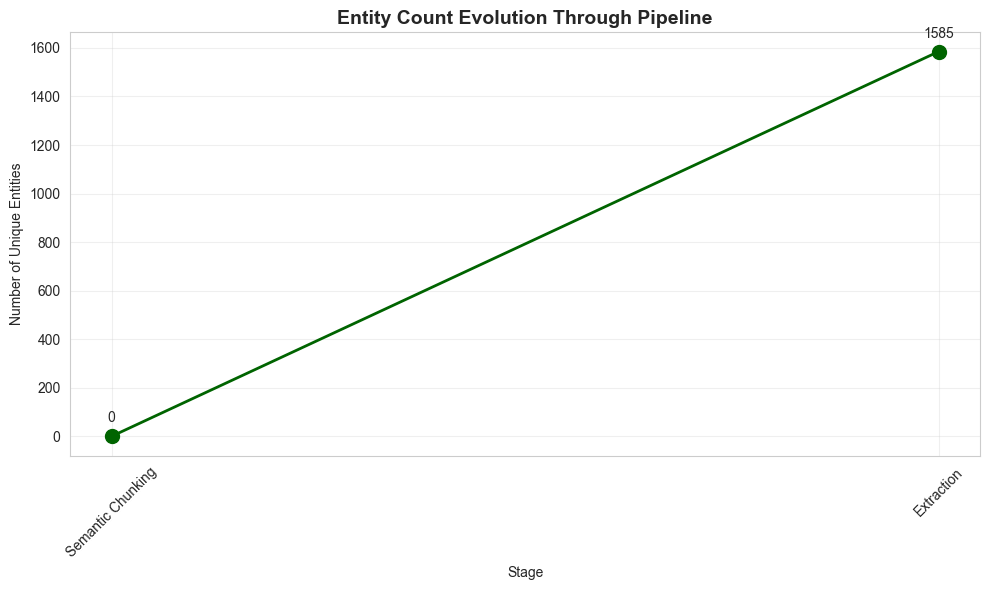


Entity Count by Stage:
            Stage  Entity Count
Semantic Chunking             0
       Extraction          1585


In [11]:
if len(stage_stats) >= 2:
    # Track entity counts through stages
    entity_evolution = []
    
    for stage in STAGES:
        if stage in stage_stats:
            entities = stage_stats[stage]["all_entities"]
            entity_evolution.append({
                "Stage": stage.replace("_", " ").title(),
                "Entity Count": len(entities)
            })
    
    if entity_evolution:
        df_entities = pd.DataFrame(entity_evolution)
        
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(df_entities["Stage"], df_entities["Entity Count"], 
                marker='o', linewidth=2, markersize=10, color='darkgreen')
        ax.set_title("Entity Count Evolution Through Pipeline", fontsize=14, fontweight='bold')
        ax.set_xlabel("Stage")
        ax.set_ylabel("Number of Unique Entities")
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        
        # Add value labels on points
        for idx, row in df_entities.iterrows():
            ax.annotate(row["Entity Count"], 
                       (idx, row["Entity Count"]), 
                       textcoords="offset points", 
                       xytext=(0,10), 
                       ha='center')
        
        plt.tight_layout()
        plt.show()
        
        print("\nEntity Count by Stage:")
        print(df_entities.to_string(index=False))

## Compare Extracted Triples with Ground Truth Entities

In [12]:
from difflib import SequenceMatcher

def normalize_entity_name(text: str) -> str:
    """Normalize entity name for comparison."""
    if not text:
        return ""
    text = text.lower().strip()
    # Remove common prefixes
    text = text.replace("the ", "").replace("a ", "")
    # Normalize whitespace
    text = " ".join(text.split())
    return text


def entity_similarity(e1: str, e2: str, threshold: float = 0.70) -> bool:
    """Check if two entities match using fuzzy matching."""
    e1_norm = normalize_entity_name(e1)
    e2_norm = normalize_entity_name(e2)
    
    if e1_norm == e2_norm:
        return True
    
    # Containment check
    if e1_norm in e2_norm or e2_norm in e1_norm:
        if len(min(e1_norm, e2_norm, key=len)) >= 3:
            return True
    
    # Sequence similarity
    return SequenceMatcher(None, e1_norm, e2_norm).ratio() >= threshold


def extract_ground_truth_entities(batch: Dict[str, Any]) -> Set[Tuple[str, str]]:
    """Extract ground truth entities from batch meta.
    Returns set of (entity_name, entity_label) tuples.
    """
    entities = set()
    meta = batch.get("meta", {})
    
    # Try expected_entities first, then entities
    gt_entities = meta.get("expected_entities") or meta.get("entities", [])
    
    for ent in gt_entities:
        if isinstance(ent, list) and len(ent) >= 4:
            # Format: [start, end, "text", "label"]
            ent_text = str(ent[2]).strip()
            ent_label = str(ent[3]).strip() if len(ent) > 3 else ""
            if ent_text:
                entities.add((normalize_entity_name(ent_text), ent_label))
        elif isinstance(ent, dict):
            # Format: {"text": "...", "label": "..."}
            ent_text = ent.get("text", "").strip()
            ent_label = ent.get("label", "").strip()
            if ent_text:
                entities.add((normalize_entity_name(ent_text), ent_label))
    
    return entities


def extract_predicted_entities(batch: Dict[str, Any]) -> Set[str]:
    """Extract predicted entity names from triples."""
    entities = set()
    triples = batch.get("triples", [])
    
    for triple in triples:
        subj = triple.get("subject", {})
        obj = triple.get("object", {})
        
        # Extract subject
        if isinstance(subj, dict):
            subj_name = subj.get("name", "")
        else:
            subj_name = str(subj)
        
        if subj_name:
            entities.add(normalize_entity_name(subj_name))
        
        # Extract object
        if isinstance(obj, dict):
            obj_name = obj.get("name", "")
        else:
            obj_name = str(obj)
        
        if obj_name:
            entities.add(normalize_entity_name(obj_name))
    
    return entities - {""}


def compute_entity_metrics(gold_entities: Set[Tuple[str, str]], pred_entities: Set[str]) -> Dict[str, Any]:
    """Compute precision, recall, F1 for entity extraction."""
    if not gold_entities and not pred_entities:
        return {"precision": 1.0, "recall": 1.0, "f1": 1.0, "tp": 0, "fp": 0, "fn": 0,
                "gold_count": 0, "pred_count": 0}
    
    if not gold_entities:
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0, "tp": 0, "fp": len(pred_entities), "fn": 0,
                "gold_count": 0, "pred_count": len(pred_entities)}
    
    if not pred_entities:
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0, "tp": 0, "fp": 0, "fn": len(gold_entities),
                "gold_count": len(gold_entities), "pred_count": 0}
    
    # Extract just entity names from gold (ignore labels for matching)
    gold_names = {name for name, label in gold_entities}
    
    # Match predicted entities to gold entities
    matched_gold = set()
    matched_pred = set()
    
    gold_list = list(gold_names)
    pred_list = list(pred_entities)
    
    for i, pred in enumerate(pred_list):
        for j, gold in enumerate(gold_list):
            if j not in matched_gold and entity_similarity(pred, gold):
                matched_gold.add(j)
                matched_pred.add(i)
                break
    
    tp = len(matched_gold)
    fp = len(pred_entities) - len(matched_pred)
    fn = len(gold_entities) - len(matched_gold)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "gold_count": len(gold_entities),
        "pred_count": len(pred_entities),
    }


# Compare extracted entities with ground truth
if RUN_ID and stage_results:
    print("\n" + "="*80)
    print("GROUND TRUTH ENTITY COMPARISON")
    print("="*80)
    
    # Use extraction stage for comparison (or canonicalization if available)
    comparison_stage = "canonicalization" if "canonicalization" in stage_results and stage_results["canonicalization"] else "extraction"
    
    if comparison_stage in stage_results:
        batches = stage_results[comparison_stage]
        
        all_metrics = []
        per_label_metrics = defaultdict(lambda: {"tp": 0, "fp": 0, "fn": 0, "gold_count": 0, "pred_count": 0})
        
        for batch in batches:
            gold_entities = extract_ground_truth_entities(batch)
            pred_entities = extract_predicted_entities(batch)
            
            if gold_entities:  # Only evaluate batches with ground truth
                metrics = compute_entity_metrics(gold_entities, pred_entities)
                metrics["doc_id"] = batch.get("doc_id", "")
                all_metrics.append(metrics)
                
                # Per-label metrics
                gold_by_label = defaultdict(set)
                for name, label in gold_entities:
                    gold_by_label[label].add(name)
                
                # Match predictions to gold by label
                for label, gold_names in gold_by_label.items():
                    matched = 0
                    for pred in pred_entities:
                        for gold_name in gold_names:
                            if entity_similarity(pred, gold_name):
                                matched += 1
                                break
                    
                    per_label_metrics[label]["tp"] += matched
                    per_label_metrics[label]["gold_count"] += len(gold_names)
                    per_label_metrics[label]["pred_count"] += len([p for p in pred_entities if any(entity_similarity(p, g) for g in gold_names)])
        
        # Compute overall metrics
        if all_metrics:
            total_tp = sum(m["tp"] for m in all_metrics)
            total_fp = sum(m["fp"] for m in all_metrics)
            total_fn = sum(m["fn"] for m in all_metrics)
            total_gold = sum(m["gold_count"] for m in all_metrics)
            total_pred = sum(m["pred_count"] for m in all_metrics)
            
            micro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
            micro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
            micro_f1 = 2 * micro_precision * micro_recall / (micro_precision + micro_recall) if (micro_precision + micro_recall) > 0 else 0.0
            
            macro_precision = np.mean([m["precision"] for m in all_metrics])
            macro_recall = np.mean([m["recall"] for m in all_metrics])
            macro_f1 = np.mean([m["f1"] for m in all_metrics])
            
            print(f"\nStage: {comparison_stage.replace('_', ' ').title()}")
            print(f"Batches with ground truth: {len(all_metrics)}")
            print(f"\nMICRO METRICS (aggregated):")
            print(f"  Precision: {micro_precision:.4f}")
            print(f"  Recall:    {micro_recall:.4f}")
            print(f"  F1:        {micro_f1:.4f}")
            print(f"  TP: {total_tp}, FP: {total_fp}, FN: {total_fn}")
            print(f"  Gold entities: {total_gold}, Predicted entities: {total_pred}")
            
            print(f"\nMACRO METRICS (per-document average):")
            print(f"  Precision: {macro_precision:.4f}")
            print(f"  Recall:    {macro_recall:.4f}")
            print(f"  F1:        {macro_f1:.4f}")
            
            # Per-label breakdown
            if per_label_metrics:
                print(f"\nPER-LABEL METRICS:")
                label_data = []
                for label, label_stats in sorted(per_label_metrics.items()):
                    if label_stats["gold_count"] > 0:
                        tp = label_stats["tp"]
                        fp = label_stats["pred_count"] - tp
                        fn = label_stats["gold_count"] - tp
                        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
                        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
                        label_data.append({
                            "Label": label,
                            "Precision": f"{p:.4f}",
                            "Recall": f"{r:.4f}",
                            "F1": f"{f1:.4f}",
                            "TP": tp,
                            "FP": fp,
                            "FN": fn,
                            "Gold": label_stats["gold_count"],
                        })
                
                if label_data:
                    df_labels = pd.DataFrame(label_data)
                    print(df_labels.to_string(index=False))
        else:
            print(f"No batches with ground truth entities found in {comparison_stage}")
    else:
        print(f"Stage {comparison_stage} not found in results")
else:
    print("No results available for comparison")


GROUND TRUTH ENTITY COMPARISON



Stage: Extraction
Batches with ground truth: 704

MICRO METRICS (aggregated):
  Precision: 0.8248
  Recall:    0.8013
  F1:        0.8129
  TP: 2081, FP: 442, FN: 516
  Gold entities: 2597, Predicted entities: 2523

MACRO METRICS (per-document average):
  Precision: 0.7650
  Recall:    0.7846
  F1:        0.7565

PER-LABEL METRICS:
  Label Precision Recall     F1  TP  FP  FN  Gold
    ACT    1.0000 0.7839 0.8789 439   0 121   560
    APT    1.0000 0.9323 0.9650 372   0  27   399
    DOM    1.0000 0.6923 0.8182   9   0   4    13
  EMAIL    1.0000 1.0000 1.0000   2   0   0     2
   ENCR    1.0000 0.6364 0.7778   7   0   4    11
   FILE    1.0000 0.8450 0.9160 109   0  20   129
   HASH    1.0000 0.6667 0.8000  12   0   6    18
   IDTY    1.0000 0.8684 0.9295 376   0  57   433
     IP    1.0000 0.8750 0.9333   7   0   1     8
    LOC    1.0000 0.9686 0.9840 154   0   5   159
    MAL    1.0000 0.9377 0.9679 286   0  19   305
     OS    1.0000 0.8837 0.9383  38   0   5    43
   PROT    1.00

## Visualize Ground Truth Comparison

## Compare Extracted Triples with Ground Truth Triples

In [13]:
def extract_ground_truth_triples(batch: Dict[str, Any]) -> Set[Tuple[str, str, str]]:
    """Extract ground truth triples from batch meta.
    Relations format: [predicate, head_idx, tail_idx] where indices refer to entities list.
    Returns set of (subject_name, predicate, object_name) tuples (normalized).
    """
    triples = set()
    meta = batch.get("meta", {})
    
    # Get entities and relations
    entities = meta.get("expected_entities") or meta.get("entities", [])
    relations = meta.get("expected_relations") or meta.get("relations", [])
    
    if not entities or not relations:
        return triples
    
    # Build entity index map: index -> entity_name
    entity_map = {}
    for i, ent in enumerate(entities):
        if isinstance(ent, list) and len(ent) >= 4:
            # Format: [start, end, "text", "label"]
            ent_text = str(ent[2]).strip()
            if ent_text:
                entity_map[i] = normalize_entity_name(ent_text)
        elif isinstance(ent, dict):
            ent_text = ent.get("text", "").strip()
            if ent_text:
                entity_map[i] = normalize_entity_name(ent_text)
    
    # Build triples from relations
    for rel in relations:
        if not isinstance(rel, list) or len(rel) < 3:
            continue
        
        pred = str(rel[0]).strip().lower()
        head_idx = rel[1]  # object index
        tail_idx = rel[2]  # subject index
        
        # Skip "noRelation" predicates
        if pred in ["norelation", "no_relation", "none"]:
            continue
        
        # Get entity names from indices
        subj_name = entity_map.get(tail_idx)
        obj_name = entity_map.get(head_idx)
        
        if subj_name and obj_name and pred:
            # Normalize predicate
            pred = normalize_predicate(pred)
            triples.add((subj_name, pred, obj_name))
    
    return triples


def normalize_predicate(pred: str) -> str:
    """Normalize predicate to standard form by removing punctuation and handling variations."""
    if not pred:
        return ""
    
    # Convert to lowercase and strip
    pred = pred.lower().strip()
    
    # Remove all hyphens, underscores, and spaces for comparison
    # This handles cases like "affiliated-with" vs "affiliatedwith" vs "affiliated_with"
    pred_normalized = pred.replace("-", "").replace("_", "").replace(" ", "")
    
    # Common variations (singular/plural, verb forms)
    # These map to canonical forms (still without punctuation)
    variations = {
        "use": "uses",
        "using": "uses",
        "target": "targets",
        "targeting": "targets",
        "exploit": "exploits",
        "exploiting": "exploits",
        "type": "types",  # if someone says "type" instead of "type_of"
    }
    
    # Apply variation mapping if exists, otherwise use normalized form
    canonical = variations.get(pred_normalized, pred_normalized)
    
    # Return the canonical form (without any punctuation)
    return canonical


def extract_predicted_triples(batch: Dict[str, Any]) -> Set[Tuple[str, str, str]]:
    """Extract predicted triples from batch.
    Returns set of (subject_name, predicate, object_name) tuples (normalized).
    """
    triples = set()
    
    for triple in batch.get("triples", []):
        subj = triple.get("subject", {})
        obj = triple.get("object", {})
        pred = triple.get("predicate", "")
        
        # Extract subject name
        if isinstance(subj, dict):
            subj_name = subj.get("name", "")
        else:
            subj_name = str(subj)
        
        # Extract object name
        if isinstance(obj, dict):
            obj_name = obj.get("name", "")
        else:
            obj_name = str(obj)
        
        if subj_name and obj_name and pred:
            subj_norm = normalize_entity_name(subj_name)
            obj_norm = normalize_entity_name(obj_name)
            pred_norm = normalize_predicate(pred)
            triples.add((subj_norm, pred_norm, obj_norm))
    
    return triples


def triple_matches(gt_triple: Tuple[str, str, str], pred_triple: Tuple[str, str, str]) -> bool:
    """Check if a ground truth triple matches a predicted triple using fuzzy matching."""
    gt_subj, gt_pred, gt_obj = gt_triple
    pred_subj, pred_pred, pred_obj = pred_triple
    
    # Predicate must match exactly (after normalization)
    if gt_pred != pred_pred:
        return False
    
    # Entities must match using fuzzy matching
    subj_match = entity_similarity(gt_subj, pred_subj)
    obj_match = entity_similarity(gt_obj, pred_obj)
    
    return subj_match and obj_match


def compute_triple_metrics(gold_triples: Set[Tuple[str, str, str]], 
                          pred_triples: Set[Tuple[str, str, str]]) -> Dict[str, Any]:
    """Compute precision, recall, F1 for triple extraction."""
    if not gold_triples and not pred_triples:
        return {"precision": 1.0, "recall": 1.0, "f1": 1.0, "tp": 0, "fp": 0, "fn": 0, 
                "gold_count": 0, "pred_count": 0}
    
    if not gold_triples:
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0, "tp": 0, "fp": len(pred_triples), "fn": 0,
                "gold_count": 0, "pred_count": len(pred_triples)}
    
    if not pred_triples:
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0, "tp": 0, "fp": 0, "fn": len(gold_triples),
                "gold_count": len(gold_triples), "pred_count": 0}
    
    # Match predicted triples to gold triples
    matched_gold = set()
    matched_pred = set()
    
    gold_list = list(gold_triples)
    pred_list = list(pred_triples)
    
    for i, pred_t in enumerate(pred_list):
        for j, gold_t in enumerate(gold_list):
            if j not in matched_gold and triple_matches(gold_t, pred_t):
                matched_gold.add(j)
                matched_pred.add(i)
                break
    
    tp = len(matched_gold)
    fp = len(pred_triples) - len(matched_pred)
    fn = len(gold_triples) - len(matched_gold)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "gold_count": len(gold_triples),
        "pred_count": len(pred_triples),
    }


# Compare extracted triples with ground truth triples
if RUN_ID and stage_results:
    print("\n" + "="*80)
    print("GROUND TRUTH TRIPLE COMPARISON")
    print("="*80)
    
    # Use extraction stage for comparison (or canonicalization if available)
    comparison_stage = "canonicalization" if "canonicalization" in stage_results and stage_results["canonicalization"] else "extraction"
    
    if comparison_stage in stage_results:
        batches = stage_results[comparison_stage]
        
        all_triple_metrics = []
        per_predicate_metrics = defaultdict(lambda: {"tp": 0, "fp": 0, "fn": 0, "gold_count": 0, "pred_count": 0})
        
        for batch in batches:
            gold_triples = extract_ground_truth_triples(batch)
            pred_triples = extract_predicted_triples(batch)
            
            if gold_triples:  # Only evaluate batches with ground truth
                metrics = compute_triple_metrics(gold_triples, pred_triples)
                metrics["doc_id"] = batch.get("doc_id", "")
                all_triple_metrics.append(metrics)
                
                # Per-predicate metrics
                gold_by_pred = defaultdict(set)
                for gt_t in gold_triples:
                    gold_by_pred[gt_t[1]].add(gt_t)  # Group by predicate
                
                # Match predictions to gold by predicate
                for pred, gold_triples_for_pred in gold_by_pred.items():
                    matched = 0
                    for pred_t in pred_triples:
                        if pred_t[1] == pred:  # Same predicate
                            for gold_t in gold_triples_for_pred:
                                if triple_matches(gold_t, pred_t):
                                    matched += 1
                                    break
                    
                    per_predicate_metrics[pred]["tp"] += matched
                    per_predicate_metrics[pred]["gold_count"] += len(gold_triples_for_pred)
                    per_predicate_metrics[pred]["pred_count"] += len([t for t in pred_triples if t[1] == pred])
        
        # Compute overall metrics
        if all_triple_metrics:
            total_tp = sum(m["tp"] for m in all_triple_metrics)
            total_fp = sum(m["fp"] for m in all_triple_metrics)
            total_fn = sum(m["fn"] for m in all_triple_metrics)
            total_gold = sum(m["gold_count"] for m in all_triple_metrics)
            total_pred = sum(m["pred_count"] for m in all_triple_metrics)
            
            micro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
            micro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
            micro_f1 = 2 * micro_precision * micro_recall / (micro_precision + micro_recall) if (micro_precision + micro_recall) > 0 else 0.0
            
            macro_precision = np.mean([m["precision"] for m in all_triple_metrics])
            macro_recall = np.mean([m["recall"] for m in all_triple_metrics])
            macro_f1 = np.mean([m["f1"] for m in all_triple_metrics])
            
            print(f"\nStage: {comparison_stage.replace('_', ' ').title()}")
            print(f"Batches with ground truth triples: {len(all_triple_metrics)}")
            print(f"\nMICRO METRICS (aggregated):")
            print(f"  Precision: {micro_precision:.4f}")
            print(f"  Recall:    {micro_recall:.4f}")
            print(f"  F1:        {micro_f1:.4f}")
            print(f"  TP: {total_tp}, FP: {total_fp}, FN: {total_fn}")
            print(f"  Gold triples: {total_gold}, Predicted triples: {total_pred}")
            
            print(f"\nMACRO METRICS (per-document average):")
            print(f"  Precision: {macro_precision:.4f}")
            print(f"  Recall:    {macro_recall:.4f}")
            print(f"  F1:        {macro_f1:.4f}")
            
            # Per-predicate breakdown
            if per_predicate_metrics:
                print(f"\nPER-PREDICATE METRICS:")
                predicate_data = []
                for pred, pred_stats in sorted(per_predicate_metrics.items()):
                    if pred_stats["gold_count"] > 0:
                        tp = pred_stats["tp"]
                        fp = pred_stats["pred_count"] - tp
                        fn = pred_stats["gold_count"] - tp
                        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
                        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
                        predicate_data.append({
                            "Predicate": pred,
                            "Precision": f"{p:.4f}",
                            "Recall": f"{r:.4f}",
                            "F1": f"{f1:.4f}",
                            "TP": tp,
                            "FP": fp,
                            "FN": fn,
                            "Gold": pred_stats["gold_count"],
                        })
                
                if predicate_data:
                    df_predicates = pd.DataFrame(predicate_data)
                    print(df_predicates.to_string(index=False))
        else:
            print(f"No batches with ground truth triples found in {comparison_stage}")
    else:
        print(f"Stage {comparison_stage} not found in results")
else:
    print("No results available for triple comparison")


GROUND TRUTH TRIPLE COMPARISON



Stage: Extraction
Batches with ground truth triples: 624

MICRO METRICS (aggregated):
  Precision: 0.5193
  Recall:    0.5819
  F1:        0.5489
  TP: 1598, FP: 1479, FN: 1148
  Gold triples: 2746, Predicted triples: 3077

MACRO METRICS (per-document average):
  Precision: 0.5896
  Recall:    0.6032
  F1:        0.5555

PER-PREDICATE METRICS:
        Predicate Precision Recall     F1  TP  FP  FN  Gold
   affiliatedwith    0.7273 0.5333 0.6154   8   3   7    15
   associatedwith    0.6488 0.4404 0.5247 133  72 169   302
         contains    1.0000 1.0000 1.0000   2   0   0     2
hasattacklocation    0.8487 0.6779 0.7537 101  18  48   149
    hasattacktime    0.9615 0.7500 0.8427  75   3  25   100
      haslocation    0.9574 0.7895 0.8654  45   2  12    57
 hasvulnerability    0.2500 0.1111 0.1538   1   3   8     9
       identifies    0.8864 0.5200 0.6555  39   5  36    75
         monitors    1.0000 1.0000 1.0000   3   0   0     3
       targetedby    0.6633 0.5603 0.6075 130  66 102

## Visualize Ground Truth Triple Comparison

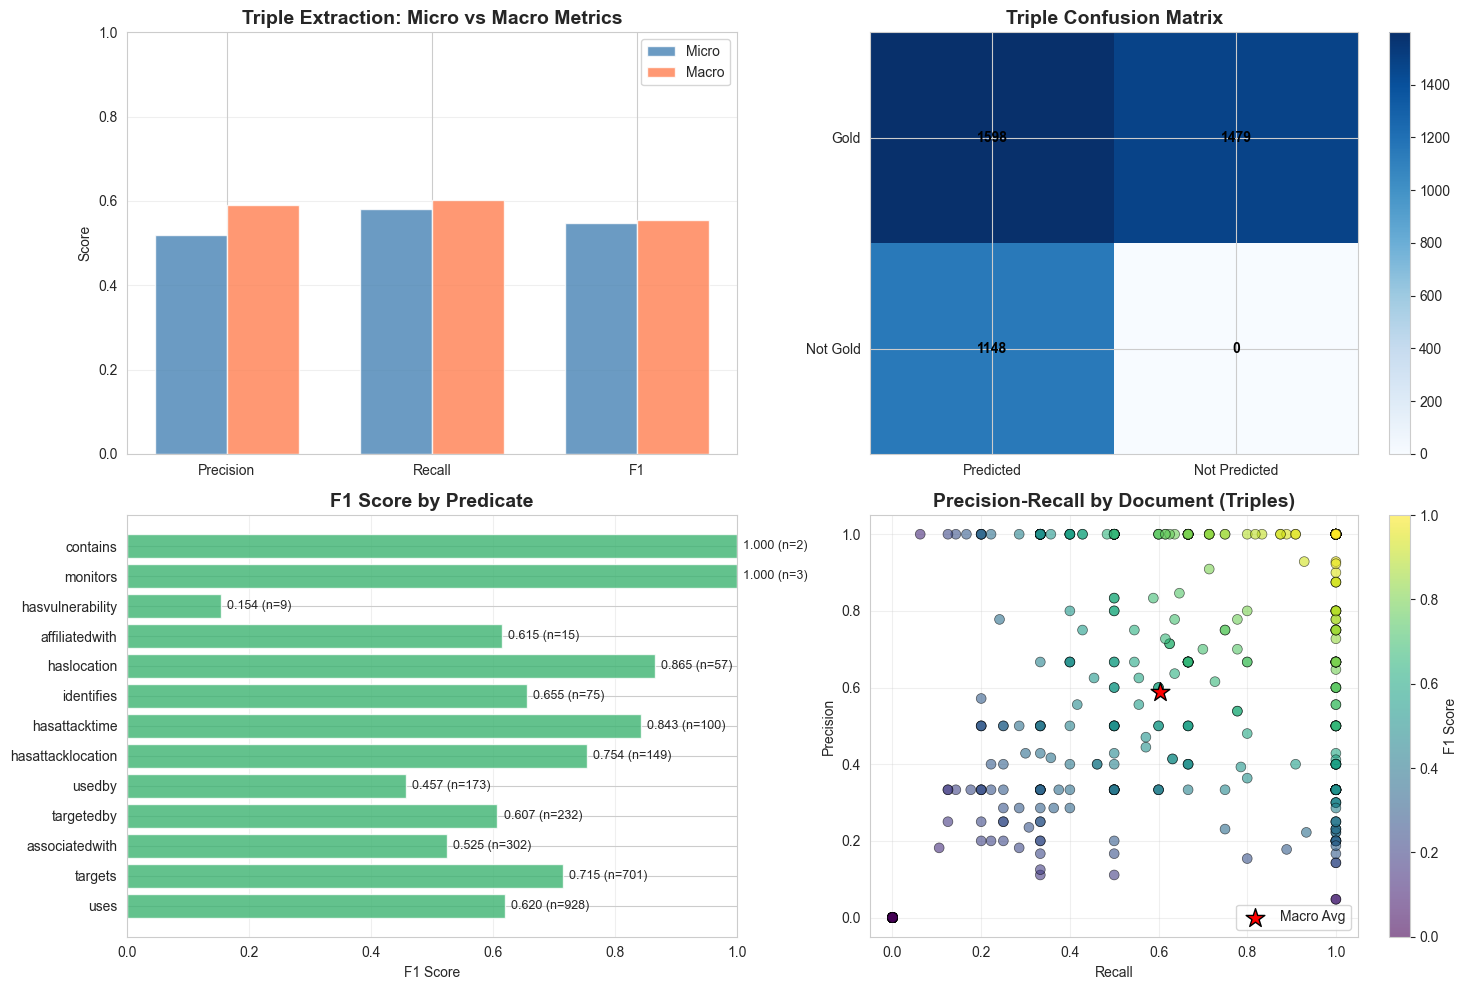


Run ID: 20260313-123818
Comparison Stage: Extraction
Total Ground Truth Triples: 2746
Total Predicted Triples: 3077


In [14]:
# Visualize the triple comparison results
if RUN_ID and stage_results and 'all_triple_metrics' in locals() and all_triple_metrics:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Precision, Recall, F1 comparison
    metrics_names = ["Precision", "Recall", "F1"]
    micro_values = [micro_precision, micro_recall, micro_f1]
    macro_values = [macro_precision, macro_recall, macro_f1]
    
    x = np.arange(len(metrics_names))
    width = 0.35
    
    axes[0, 0].bar(x - width/2, micro_values, width, label='Micro', color='steelblue', alpha=0.8)
    axes[0, 0].bar(x + width/2, macro_values, width, label='Macro', color='coral', alpha=0.8)
    axes[0, 0].set_ylabel('Score')
    axes[0, 0].set_title('Triple Extraction: Micro vs Macro Metrics', fontsize=14, fontweight='bold')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(metrics_names)
    axes[0, 0].legend()
    axes[0, 0].set_ylim([0, 1])
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # 2. Confusion matrix visualization
    confusion_data = [[total_tp, total_fp], [total_fn, 0]]
    im = axes[0, 1].imshow(confusion_data, cmap='Blues', aspect='auto')
    axes[0, 1].set_xticks([0, 1])
    axes[0, 1].set_yticks([0, 1])
    axes[0, 1].set_xticklabels(['Predicted', 'Not Predicted'])
    axes[0, 1].set_yticklabels(['Gold', 'Not Gold'])
    axes[0, 1].set_title('Triple Confusion Matrix', fontsize=14, fontweight='bold')
    
    # Add text annotations
    for i in range(2):
        for j in range(2):
            text = axes[0, 1].text(j, i, confusion_data[i][j],
                                 ha="center", va="center", color="black", fontweight='bold')
    
    # Add colorbar
    plt.colorbar(im, ax=axes[0, 1])
    
    # 3. Per-predicate F1 scores
    if per_predicate_metrics:
        predicate_data = []
        for pred, pred_stats in sorted(per_predicate_metrics.items()):
            if pred_stats["gold_count"] > 0:
                tp = pred_stats["tp"]
                fp = pred_stats["pred_count"] - tp
                fn = pred_stats["gold_count"] - tp
                p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
                r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
                predicate_data.append((pred, f1, pred_stats["gold_count"]))
        
        if predicate_data:
            predicates_sorted = sorted(predicate_data, key=lambda x: x[2], reverse=True)  # Sort by gold count
            pred_names = [p[0] for p in predicates_sorted]
            f1_scores = [p[1] for p in predicates_sorted]
            gold_counts = [p[2] for p in predicates_sorted]
            
            bars = axes[1, 0].barh(pred_names, f1_scores, color='mediumseagreen', alpha=0.8)
            axes[1, 0].set_xlabel('F1 Score')
            axes[1, 0].set_title('F1 Score by Predicate', fontsize=14, fontweight='bold')
            axes[1, 0].set_xlim([0, 1])
            axes[1, 0].grid(True, alpha=0.3, axis='x')
            
            # Add value labels
            for i, (bar, score, count) in enumerate(zip(bars, f1_scores, gold_counts)):
                axes[1, 0].text(score + 0.01, i, f"{score:.3f} (n={count})",
                              va='center', fontsize=9)
    
    # 4. Precision-Recall scatter by document
    if len(all_triple_metrics) > 1:
        precisions = [m["precision"] for m in all_triple_metrics]
        recalls = [m["recall"] for m in all_triple_metrics]
        f1s = [m["f1"] for m in all_triple_metrics]
        
        scatter = axes[1, 1].scatter(recalls, precisions, c=f1s, cmap='viridis', 
                                    s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
        axes[1, 1].set_xlabel('Recall')
        axes[1, 1].set_ylabel('Precision')
        axes[1, 1].set_title('Precision-Recall by Document (Triples)', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlim([-0.05, 1.05])
        axes[1, 1].set_ylim([-0.05, 1.05])
        axes[1, 1].grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=axes[1, 1], label='F1 Score')
        
        # Add average point
        axes[1, 1].scatter([macro_recall], [macro_precision], 
                          s=200, marker='*', color='red', edgecolors='black', 
                          linewidth=1, label='Macro Avg', zorder=5)
        axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nRun ID: {RUN_ID}")
    print(f"Comparison Stage: {comparison_stage.replace('_', ' ').title()}")
    print(f"Total Ground Truth Triples: {total_gold}")
    print(f"Total Predicted Triples: {total_pred}")
else:
    print("No ground truth triple comparison data available for visualization")

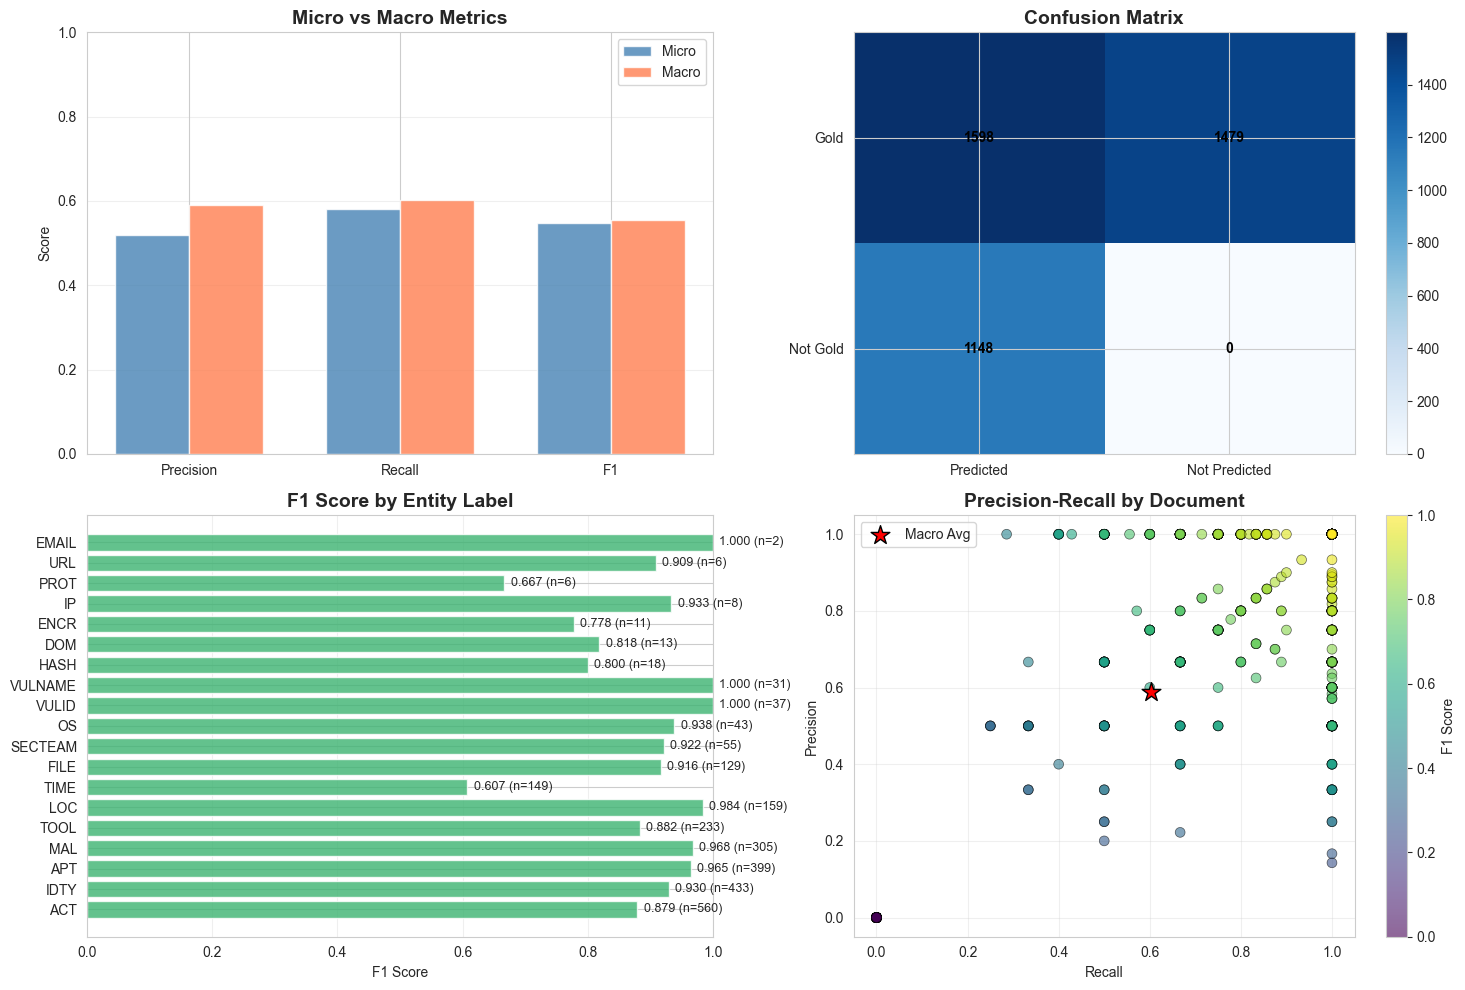


Run ID: 20260313-123818
Comparison Stage: Extraction


In [15]:
# Visualize the comparison results
if RUN_ID and stage_results and 'all_metrics' in locals() and all_metrics:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Precision, Recall, F1 comparison
    metrics_names = ["Precision", "Recall", "F1"]
    micro_values = [micro_precision, micro_recall, micro_f1]
    macro_values = [macro_precision, macro_recall, macro_f1]
    
    x = np.arange(len(metrics_names))
    width = 0.35
    
    axes[0, 0].bar(x - width/2, micro_values, width, label='Micro', color='steelblue', alpha=0.8)
    axes[0, 0].bar(x + width/2, macro_values, width, label='Macro', color='coral', alpha=0.8)
    axes[0, 0].set_ylabel('Score')
    axes[0, 0].set_title('Micro vs Macro Metrics', fontsize=14, fontweight='bold')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(metrics_names)
    axes[0, 0].legend()
    axes[0, 0].set_ylim([0, 1])
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # 2. Confusion matrix visualization
    confusion_data = [[total_tp, total_fp], [total_fn, 0]]
    im = axes[0, 1].imshow(confusion_data, cmap='Blues', aspect='auto')
    axes[0, 1].set_xticks([0, 1])
    axes[0, 1].set_yticks([0, 1])
    axes[0, 1].set_xticklabels(['Predicted', 'Not Predicted'])
    axes[0, 1].set_yticklabels(['Gold', 'Not Gold'])
    axes[0, 1].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
    
    # Add text annotations
    for i in range(2):
        for j in range(2):
            text = axes[0, 1].text(j, i, confusion_data[i][j],
                                 ha="center", va="center", color="black", fontweight='bold')
    
    # Add colorbar
    plt.colorbar(im, ax=axes[0, 1])
    
    # 3. Per-label F1 scores
    if per_label_metrics:
        label_data = []
        for label, label_stats in sorted(per_label_metrics.items()):
            if label_stats["gold_count"] > 0:
                tp = label_stats["tp"]
                fp = label_stats["pred_count"] - tp
                fn = label_stats["gold_count"] - tp
                p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
                r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
                label_data.append((label, f1, label_stats["gold_count"]))
        
        if label_data:
            labels_sorted = sorted(label_data, key=lambda x: x[2], reverse=True)  # Sort by gold count
            label_names = [l[0] for l in labels_sorted]
            f1_scores = [l[1] for l in labels_sorted]
            gold_counts = [l[2] for l in labels_sorted]
            
            bars = axes[1, 0].barh(label_names, f1_scores, color='mediumseagreen', alpha=0.8)
            axes[1, 0].set_xlabel('F1 Score')
            axes[1, 0].set_title('F1 Score by Entity Label', fontsize=14, fontweight='bold')
            axes[1, 0].set_xlim([0, 1])
            axes[1, 0].grid(True, alpha=0.3, axis='x')
            
            # Add value labels
            for i, (bar, score, count) in enumerate(zip(bars, f1_scores, gold_counts)):
                axes[1, 0].text(score + 0.01, i, f"{score:.3f} (n={count})",
                              va='center', fontsize=9)
    
    # 4. Precision-Recall scatter by document
    if len(all_metrics) > 1:
        precisions = [m["precision"] for m in all_metrics]
        recalls = [m["recall"] for m in all_metrics]
        f1s = [m["f1"] for m in all_metrics]
        
        scatter = axes[1, 1].scatter(recalls, precisions, c=f1s, cmap='viridis', 
                                    s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
        axes[1, 1].set_xlabel('Recall')
        axes[1, 1].set_ylabel('Precision')
        axes[1, 1].set_title('Precision-Recall by Document', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlim([-0.05, 1.05])
        axes[1, 1].set_ylim([-0.05, 1.05])
        axes[1, 1].grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=axes[1, 1], label='F1 Score')
        
        # Add average point
        axes[1, 1].scatter([macro_recall], [macro_precision], 
                          s=200, marker='*', color='red', edgecolors='black', 
                          linewidth=1, label='Macro Avg', zorder=5)
        axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nRun ID: {RUN_ID}")
    print(f"Comparison Stage: {comparison_stage.replace('_', ' ').title()}")
else:
    print("No ground truth comparison data available for visualization")

## Export Comparison Report

In [16]:
if stage_stats and RUN_ID:
    # Create a comprehensive report
    report = {
        "run_id": RUN_ID,
        "timestamp": datetime.now().isoformat(),
        "stages": {}
    }
    
    for stage, stats in stage_stats.items():
        report["stages"][stage] = {
            "total_batches": stats["total_batches"],
            "total_documents": stats["total_documents"],
            "total_triples": stats["total_triples"],
            "total_unique_entities": stats["total_unique_entities"],
            "avg_triples_per_batch": stats["avg_triples_per_batch"],
            "top_predicates": stats["top_predicates"],
            "top_entity_types": stats["top_entity_types"],
        }
    
    # Save report
    report_path = Path(f"../results/triple_extraction/comparison_report_{RUN_ID}.json")
    with open(report_path, 'w', encoding='utf-8') as f:
        json.dump(report, f, indent=2, ensure_ascii=False)
    
    print(f"\nÃ¢Å“â€œ Comparison report saved to: {report_path}")
    print(f"  Run ID: {RUN_ID}")
    print(f"  Stages analyzed: {len(report['stages'])}")


Ã¢Å“â€œ Comparison report saved to: ..\results\triple_extraction\comparison_report_20260313-123818.json
  Run ID: 20260313-123818
  Stages analyzed: 2
